### Importing Libraries

In [37]:
# Crop Yield Prediction# --- Core Python & Data Handling ---
import os
import json
import warnings
import numpy as np
import pandas as pd

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec


# --- Model Libraries ---
import joblib
import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, explained_variance_score
from sklearn.multioutput import MultiOutputRegressor

# --- Misc ---
warnings.filterwarnings('ignore')

# Crop Yield Prediction

In [38]:
# Load the Dataset
df = pd.read_csv('data/Crop_Yield.csv')

In [39]:
df['season'] = df['season'].str.strip().str.lower().str.title()
df['state'] = df['state'].str.strip().str.lower().str.title()
df['crop'] = df['crop'].str.strip().str.lower().str.title()
# Standardizing crop names (keeping them simple)
crop_corrections = {
    'bajra': 'pearl_millet',
    'barley': 'barley',
    'groundnut': 'groundnut',
    'maize': 'maize',
    'onion': 'onion',
    'potato': 'potato',
    'rice': 'rice',
    'sugarcane': 'sugarcane',
    'sunflower': 'sunflower',
    'wheat': 'wheat'
}
df['crop'] = df['crop'].replace(crop_corrections)
print("Unique Seasons:", df['season'].unique())
print("Unique States:", df['state'].unique())
print("Unique Crops:", df['crop'].unique())### Feature Encoding

Unique Seasons: ['Kharif' 'Whole Year' 'Autumn' 'Summer' 'Winter' 'Rabi']
Unique States: ['Assam' 'Karnataka' 'Meghalaya' 'West Bengal' 'Puducherry' 'Goa' 'Kerala'
 'Andhra Pradesh' 'Tamil Nadu' 'Odisha' 'Bihar' 'Gujarat' 'Madhya Pradesh'
 'Maharashtra' 'Mizoram' 'Punjab' 'Uttar Pradesh' 'Haryana'
 'Himachal Pradesh' 'Tripura' 'Nagaland' 'Chhattisgarh' 'Uttarakhand'
 'Jharkhand' 'Delhi' 'Manipur' 'Jammu And Kashmir' 'Telangana'
 'Arunachal Pradesh' 'Sikkim']
Unique Crops: ['Maize' 'Onion' 'Potato' 'Rice' 'Sugarcane' 'Wheat' 'Bajra' 'Groundnut'
 'Barley' 'Sunflower']


### Feature Encoding

In [40]:
le_season = LabelEncoder()
le_state = LabelEncoder()
le_crop = LabelEncoder()

df['season_enc'] = le_season.fit_transform(df['season'])
df['state_enc'] = le_state.fit_transform(df['state'])
df['crop_enc'] = le_crop.fit_transform(df['crop'])

features = ['area', 'annual rainfall', 'season_enc', 'state_enc', 'crop_enc', 'year']
target = 'production'

X = df[features]
y = df[target]

### Train dataset & Model Evaluation

In [41]:
### Split dataset into train and testscaler = StandardScaler()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [42]:
# Convert to DMatrix (required for xgb.cv)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define base parameters
params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.1,
    'max_depth': 5,
    'subsample': 1.0,
    'eval_metric': 'rmse'
}

# Perform Cross-Validation
cv_results = xgb.cv(
    params=params,
    dtrain=dtrain,
    num_boost_round=300,  # Higher value for better tuning
    nfold=5,  # More folds for better validation
    early_stopping_rounds=10,
    metrics='rmse',
    as_pandas=True,
    seed=42
)

# Best number of boosting rounds based on RMSE
best_num_boost_round = cv_results['test-rmse-mean'].idxmin() + 1  # +1 to account for 1-based index in boosting rounds
print(f"✅ Best Boosting Rounds: {best_num_boost_round}")

# Train final model with best rounds
final_model = xgb.train(params, dtrain, num_boost_round=best_num_boost_round)

# Predict on test data
y_pred = final_model.predict(dtest)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"\n📊 Model Evaluation:\n🔹 R² Score: {r2:.4f}\n🔹 Mean Squared Error: {mse:.2f}")


✅ Best Boosting Rounds: 166

📊 Model Evaluation:
🔹 R² Score: 0.9738
🔹 Mean Squared Error: 2660490182438.83


# Rainfall Forecast

In [43]:
rainfall_df = pd.read_csv('data/Rainfall.csv')

In [44]:
rainfall_df.fillna(rainfall_df.mean(numeric_only=True), inplace=True)

### Feature Encoding

In [45]:
# ✅ Features & Target
features = ['year', 'JF', 'MAM', 'JJAS', 'OND']
target = 'annual rainfall'

X = rainfall_df[features]
y = rainfall_df[target]

### Train dataset & Model Evaluation

In [46]:
# ✅ Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
# ✅ Train Rainfall Prediction Model (RandomForest)
rainfall_model = RandomForestRegressor(n_estimators=100, random_state=42)
rainfall_model.fit(X_train, y_train)

# ✅ Predict and Evaluate
y_pred = rainfall_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"✅ Rainfall Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.2f}\n")

✅ Rainfall Model Performance:
R² Score: 0.9793
MSE: 19786.36



# NPK, Temperature and Humidity prediction

In [48]:
crop_data = pd.read_csv('data/crop_data.csv')

In [49]:
# --- 1. Rename crops ---
crop_rename_map = {
    'Green Banana': 'Banana',
    'Raddish': 'Radish',
    'Paddy': 'Rice'
}
crop_data['CROP'] = crop_data['CROP'].replace(crop_rename_map)

# --- 2. Rename states ---
state_rename_map = {
    'Uttrakhand': 'Uttarakhand'
}
crop_data['STATE'] = crop_data['STATE'].replace(state_rename_map)

# --- 3. Rename soil types ---
soil_rename_map = {
    'Desert soils': 'Desert soil',
    'Clayey soils': 'Clayey soil',
    'Mountain soil.': 'Mountain soil',
    'Regur soil':'Black soil'
}
crop_data['SOIL_TYPE'] = crop_data['SOIL_TYPE'].replace(soil_rename_map)

def clean_soil_name(soil):
    soil = soil.strip().replace('.', '')  # remove trailing dot if any
    if not soil.lower().endswith('soil'):
        soil += ' soil'
    return soil

crop_data['SOIL_TYPE'] = crop_data['SOIL_TYPE'].apply(clean_soil_name)


### Feature Encoding

In [50]:
# Encode categorical columns
le_state = LabelEncoder()
le_soil = LabelEncoder()
le_crop = LabelEncoder()

crop_data['STATE_ENC'] = le_state.fit_transform(crop_data['STATE'])
crop_data['SOIL_ENC'] = le_soil.fit_transform(crop_data['SOIL_TYPE'])
crop_data['CROP_ENC'] = le_crop.fit_transform(crop_data['CROP'])


### Train dataset & Model Evaluation

In [51]:
# ✅ NPK Prediction Model
X_npk = crop_data[['STATE_ENC', 'SOIL_ENC', 'CROP_ENC', 'TEMPERATURE', 'HUMIDITY', 'RAINFALL', 'ph']]
y_npk = crop_data[['N_SOIL', 'P_SOIL', 'K_SOIL']]

X_train, X_test, y_train, y_test = train_test_split(X_npk, y_npk, test_size=0.2, random_state=42)


In [52]:
# XGBoost Regressor (Tuned)
xgb_npk_model = XGBRegressor(
    max_depth=10,
    n_estimators=200,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)
xgb_npk_model.fit(X_train, y_train)

# Evaluate NPK Model
xgb_npk_pred = xgb_npk_model.predict(X_test)
npk_r2 = r2_score(y_test, xgb_npk_pred)
print(f"✅ NPK Model Performance:")
print(f"R² Score: {npk_r2:.4f}")
print(f"MSE: {mse:.2f}\n")


✅ NPK Model Performance:
R² Score: 0.8823
MSE: 19786.36



<Figure size 1000x600 with 0 Axes>

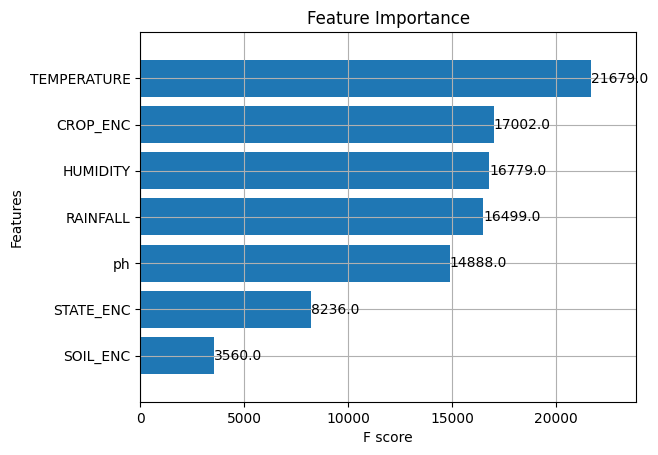

In [53]:
from xgboost import plot_importance
# Plot feature importance
plt.figure(figsize=(10, 6))
plot_importance(xgb_npk_model, importance_type='weight', max_num_features=10, height=0.8)
plt.title('Feature Importance')
plt.show()



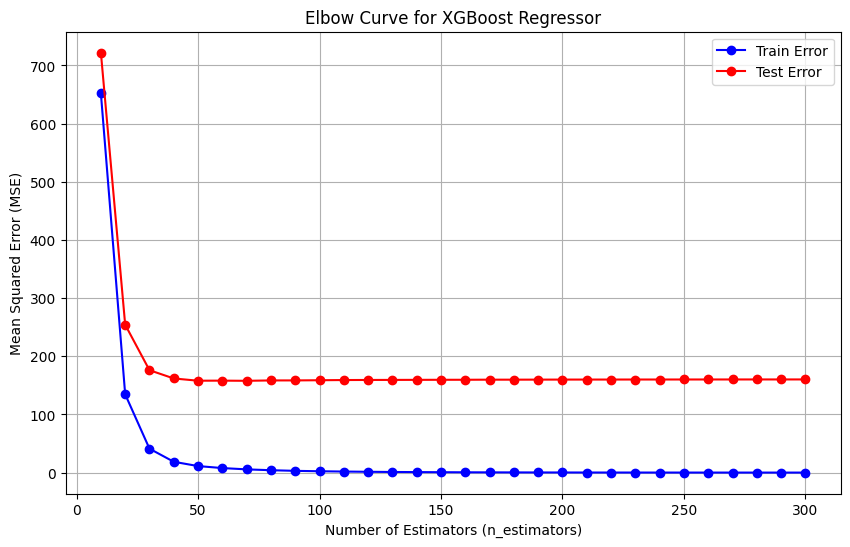

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Range of n_estimators to test
n_estimators_range = range(10, 301, 10)
train_errors = []
test_errors = []

# Train and evaluate the model for each n_estimators value
for n_estimators in n_estimators_range:
    model = XGBRegressor(
        max_depth=10,
        n_estimators=n_estimators,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42
    )
    model.fit(X_train, y_train)
    
    # Calculate predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate the Mean Squared Error (MSE) for both train and test
    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)
    
    train_errors.append(train_mse)
    test_errors.append(test_mse)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_errors, label='Train Error', color='blue', marker='o')
plt.plot(n_estimators_range, test_errors, label='Test Error', color='red', marker='o')
plt.xlabel('Number of Estimators (n_estimators)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Elbow Curve for XGBoost Regressor')
plt.legend()
plt.grid(True)
plt.show()


In [55]:
# Select only encoded and numeric features
X = crop_data[['STATE_ENC', 'SOIL_ENC', 'CROP_ENC', 'RAINFALL']]
y = crop_data[['TEMPERATURE', 'HUMIDITY']]  

X_th_train, X_th_test, y_th_train, y_th_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Best Parameters from RandomizedSearchCV:
best_params = {
    'n_estimators': 600,
    'min_samples_split': 10,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'max_depth': 10
}

# Train the RandomForest model with the best parameters on both Temperature & Humidity
best_rf = RandomForestRegressor(**best_params, random_state=42)
temp_hum_model = MultiOutputRegressor(best_rf)
temp_hum_model.fit(X_th_train, y_th_train)

# Predict and evaluate
y_th_pred = temp_hum_model.predict(X_th_test)

# Calculate R² and MSE
th_r2 = r2_score(y_th_test, y_th_pred)
mse = mean_squared_error(y_th_test, y_th_pred)

# Output the performance metrics
print(f"✅Temperature & Humidity Model Performance:")
print(f"R² Score: {th_r2:.4f}")
print(f"MSE: {mse:.2f}")

✅Temperature & Humidity Model Performance:
R² Score: 0.6202
MSE: 38.14


# Yeild Prediction

In [56]:
crop_yield = pd.read_csv('data/Crop_Yield.csv')
crop_yield.columns

Index(['crop', 'year', 'season', 'state', 'area', 'production',
       'annual rainfall', 'yield'],
      dtype='object')

### Feature Encoding

In [57]:
# ✅ Encode categorical columns
le_crop = LabelEncoder()
le_season = LabelEncoder()
le_state = LabelEncoder()

crop_yield['crop_enc'] = le_crop.fit_transform(crop_yield['crop'])
crop_yield['season_enc'] = le_season.fit_transform(crop_yield['season'])
crop_yield['state_enc'] = le_state.fit_transform(crop_yield['state'])

# ✅ Define features and target
features = ['crop_enc', 'year', 'season_enc', 'state_enc', 'area', 'annual rainfall']
target = 'yield'

X = crop_yield[features]
y = crop_yield[target]

### Train dataset & Model Evaluation

In [58]:
# ✅ Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
# Train XGBoost Regressor
xgb_yield = XGBRegressor(n_estimators=300, max_depth=12, learning_rate=0.1,
                         subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_yield.fit(X_train, y_train)

# Predict using the trained model
xgb_pred = xgb_yield.predict(X_test)

# Calculate R² and MSE
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)

# Output the performance metrics
print(f"✅ Yield Model Performance")
print(f"R² Score: {xgb_r2:.4f}")
print(f"MSE: {xgb_mse:.2f}")

✅ Yield Model Performance
R² Score: 0.8544
MSE: 62.34


# Rainfall Prediction

In [60]:
rainfall = pd.read_csv('data/Cleaned_Rainfall.csv')
le_state = joblib.load('models/predict_state_encoder.pkl')

In [61]:
# Refit encoder on the updated state list
le_state = LabelEncoder()
le_state.fit(rainfall['state'])   # Fit on all unique states present in the rainfall dataset

# Save the updated encoder for future use
joblib.dump(le_state, 'models/predictt_state_encoder.pkl')

['models/predictt_state_encoder.pkl']

### Feature Encoding

In [62]:
# ✅ Encode 'state' column
rainfall['state_enc'] = le_state.transform(rainfall['state'])

# ✅ Feature and Target selection
X = rainfall[['state_enc', 'year']]
monthly_columns = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
                   'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
y = rainfall[monthly_columns]

# Replace infinite values with NaN
y = y.replace([np.inf, -np.inf], np.nan)

# Fill NaN with mean rainfall value
y.fillna(y.mean(), inplace=True)

# Ensure y is numeric
y = y.astype(float)


### Train dataset & Model Evaluation

In [63]:
# Train Monthly Rainfall Model (MultiOutput XGBoost Regressor)
rainfall_model = MultiOutputRegressor(
    XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
)
rainfall_model.fit(X, y)

# Evaluate R² and MSE on training
y_pred = rainfall_model.predict(X)

# Calculate R² and MSE
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)

# Output the performance metrics
print(f"✅ Rainfall Model Performance")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.2f}")

✅ Rainfall Model Performance
R² Score: 0.7492
MSE: 6451.41


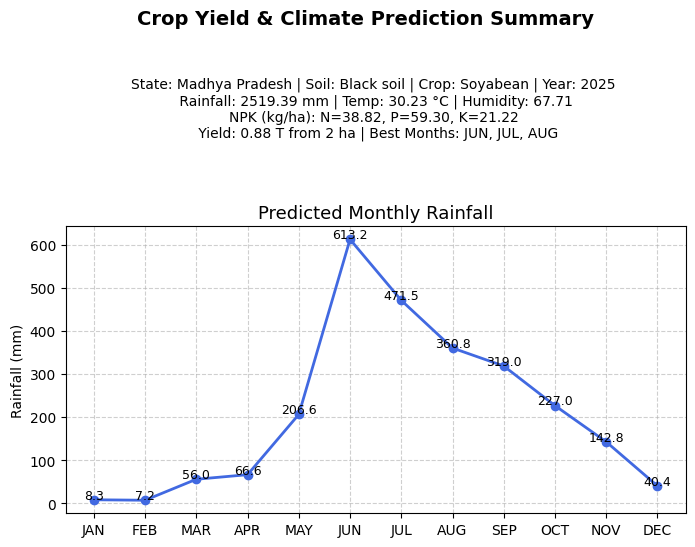

In [68]:
# Load models and encoders
npk_model = joblib.load('models/predict_npk_xgb_model.pkl')
temp_hum_model = joblib.load('models/predict_temp_hum_model.pkl')
yield_model = joblib.load('models/predict_xgb_yield_model.pkl')
rainfall_model = joblib.load('models/predict_monthly_rainfall_xgb_model.pkl')
le_state = joblib.load('models/predict_state_encoder.pkl')
le_soil = joblib.load('models/predict_soil_encoder.pkl')
le_crop = joblib.load('models/predict_crop_encoder.pkl')

# User Inputs
user_state = 'Madhya Pradesh'
user_soil = 'Black soil'
user_crop = 'Soyabean'
user_area = 2  # hectares
predict_year = 2025

# Encode Inputs
state_enc = le_state.transform([user_state])[0]
soil_enc = le_soil.transform([user_soil])[0]
crop_enc = le_crop.transform([user_crop])[0]

# Predict Rainfall
# Use the same feature names used during training: 'state_enc' and 'year'
rainfall_input = pd.DataFrame([[state_enc, predict_year]], columns=['state_enc', 'year'])
monthly_rainfall = rainfall_model.predict(rainfall_input)[0]
annual_rainfall = np.sum(monthly_rainfall)
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
rainfall_df = pd.DataFrame({'Month': months, 'Rainfall_mm': monthly_rainfall})
best_months_text = ", ".join(rainfall_df.sort_values(by='Rainfall_mm', ascending=False).head(3)['Month'].values)

# Predict Temperature & Humidity
temp_hum_input = pd.DataFrame([[state_enc, soil_enc, crop_enc, annual_rainfall]],
                              columns=['STATE_ENC', 'SOIL_ENC', 'CROP_ENC', 'RAINFALL'])
pred_temp, pred_hum = temp_hum_model.predict(temp_hum_input)[0]

# Predict NPK
ph_value = 6.5
npk_input = pd.DataFrame([[state_enc, soil_enc, crop_enc, pred_temp, pred_hum, annual_rainfall, ph_value]],
                         columns=['STATE_ENC', 'SOIL_ENC', 'CROP_ENC', 'TEMPERATURE', 'HUMIDITY', 'RAINFALL', 'ph'])
pred_N, pred_P, pred_K = npk_model.predict(npk_input)[0]

# Predict Yield
yield_input = pd.DataFrame([{
    'crop_enc': crop_enc,
    'year': predict_year,
    'season_enc': 1,
    'state_enc': state_enc,
    'area': user_area,
    'annual rainfall': annual_rainfall
}])
predicted_yield = max(0, yield_model.predict(yield_input)[0])

# Plotting
fig = plt.figure(figsize=(8, 6))
gs = GridSpec(2, 1, height_ratios=[0.4, 1], hspace=0.3)

# Top subplot - Single line summary
ax1 = fig.add_subplot(gs[0])
ax1.axis('off')
summary_text = (
    f"State: {user_state} | Soil: {user_soil} | Crop: {user_crop} | Year: {predict_year} \n "
    f"Rainfall: {annual_rainfall:.2f} mm | Temp: {pred_temp:.2f} °C | Humidity: {pred_hum:.2f} \n"
    f"NPK (kg/ha): N={pred_N:.2f}, P={pred_P:.2f}, K={pred_K:.2f} \n "
    f"Yield: {predicted_yield:.2f} T from {user_area} ha | Best Months: {best_months_text}"
)
ax1.text(0.5, 0.5, summary_text, ha='center', va='center', fontsize=10)

# Bottom subplot - Rainfall Graph
ax2 = fig.add_subplot(gs[1])
ax2.plot(rainfall_df['Month'], rainfall_df['Rainfall_mm'], marker='o', color='royalblue', linewidth=2)
for i, value in enumerate(rainfall_df['Rainfall_mm']):
    ax2.text(i, value + 2, f'{value:.1f}', ha='center', fontsize=9)
ax2.set_title('Predicted Monthly Rainfall', fontsize=13)
ax2.set_ylabel('Rainfall (mm)')
ax2.grid(True, linestyle='--', alpha=0.6)

# Final Adjustments
plt.suptitle('Crop Yield & Climate Prediction Summary', fontsize=14, fontweight='bold', y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


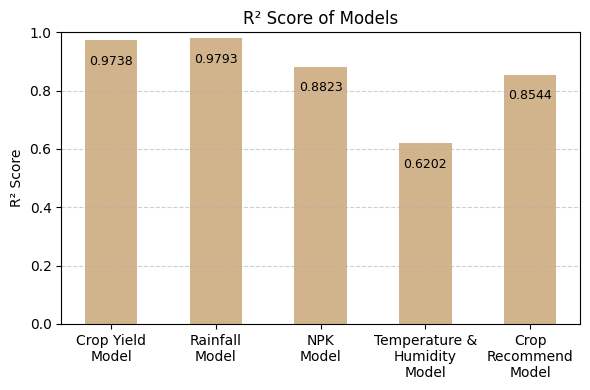

In [65]:
import matplotlib.pyplot as plt

# Model Evaluation metrics
models = [
    'Crop Yield\nModel',
    'Rainfall\nModel',
    'NPK\nModel',
    'Temperature &\nHumidity\nModel',
    'Crop\nRecommend\nModel'
]
r2_scores = [0.9738, 0.9793, 0.8823, 0.6202, 0.8544]

# Plotting
plt.figure(figsize=(6, 4))
bars = plt.bar(models, r2_scores, color='tan', width=0.5)

# Add score labels inside bars
for bar, score in zip(bars, r2_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height - 0.05, f'{score:.4f}',
             ha='center', va='top', color='black', fontsize=9)

plt.title('R² Score of Models')
plt.ylabel('R² Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [66]:
import plotly.graph_objects as go

# Model Evaluation metrics
models = [
    'Crop Yield<br>Model',
    'Rainfall<br>Model',
    'NPK<br>Model',
    'Temperature &<br>Humidity<br> Model',
    'Crop<br> Recommend<br> Model'
]
r2_scores = [0.9738, 0.9793, 0.8823, 0.6202, 0.8544]

# Create interactive bar chart
fig = go.Figure(data=[
    go.Bar(
        x=models,
        y=r2_scores,
        marker_color='tan',
        width=[0.3]*len(models),
        text=[f"{score:.4f}" for score in r2_scores],
        textposition='inside',
        textangle=0,
        hovertemplate='%{x}<br>R² Score: %{y:.4f}<extra></extra>'
    )
])

fig.update_layout(
    title='R² Score of Models',
    width=600,
    height=400,
    yaxis=dict(title='R² Score', range=[0, 1]),
    xaxis_tickangle=0,
    template='plotly_white',
    bargap=0.2,
    bargroupgap=0.1
)

plt.show()
